**TGA Analysis**

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get current working directory
current_dir = Path.cwd()

# Go 2 folders up
base_dir = current_dir.parent.parent.parent

# Build the target path
target_dir = base_dir / "Measurements" / "CNT Dispersions" / "TGA" / "Alexandra"

A = next(target_dir.glob("pristinecnt.csv"))
B = next(target_dir.glob("cnt+pyrene.csv"))
C  = next(target_dir.glob("comocats.csv"))


In [2]:
dfA = pd.read_csv(A)
dfB = pd.read_csv(B)
dfC = pd.read_csv(C)


#Required fix for dfA since I started with the wrong ininial mass
#df_A_fixed = dfA.copy()

# Step 1: flip sign
#mass = -df_A_fixed["Unsubtracted Weight"]

# Step 2: convert to decreasing mass (like normal TGA)#
#mass = mass.iloc[0] - (mass - mass.iloc[0])

# Replace column
#df_A_fixed["Unsubtracted Weight"] = mass

DFs = [dfA, dfB, dfC]


In [3]:
def process_tga(df):
    df = df.dropna(subset=["Sample Temperature", "Unsubtracted Weight"])
    
    temp = df["Sample Temperature"]
    mass = df["Unsubtracted Weight"]
    
    # Find maximum temperature (robust to fluctuations)
    max_idx = temp.idxmax()
    
    # Keep only heating portion
    df_heating = df.loc[:max_idx].copy()
    
    temp_f = df_heating["Sample Temperature"]
    mass_f = df_heating["Unsubtracted Weight"].abs()
    
#    temp_f = temp
 #   mass_f = mass
    
    # Better estimate of initial mass
    m0 = mass_f.head(10).mean()
    
    # Mass remaining percentage (starts at ~100%)
    mass_pct = mass_f / m0 * 100
    
    return pd.DataFrame({
        "Temperature": temp_f,
        "Mass (%)": mass_pct
    })

TGA_DFs = [process_tga(df) for df in DFs]


In [4]:
TGA_DFs[0]

,Temperature,Mass (%)
0,29.63,100.001801
1,29.62,100.001088
2,29.61,100.000553
3,29.59,100.000196
4,29.58,99.999839
...,...,...
2609,796.03,23.290097
2610,796.73,23.243722
2611,807.96,23.198418
2612,822.76,23.154540


In [5]:
TGA_DFs[1]

,Temperature,Mass (%)
0,30.30,100.019056
1,30.29,100.015319
2,30.28,100.011325
3,30.28,100.006948
4,30.27,100.002700
...,...,...
2609,793.94,19.467494
2610,799.16,19.423311
2611,810.49,19.381557
2612,824.98,19.337502


In [6]:
TGA_DFs[2]

,Temperature,Mass (%)
0,50.13,100.233129
1,50.12,100.175652
2,50.09,100.120164
3,50.06,100.066827
4,50.02,100.015641
...,...,...
5099,798.27,72.386453
5100,797.45,72.377152
5101,800.75,72.350053
5102,815.87,72.324030


In [7]:
def plot_tga(data):
    plt.figure()
    
    # Single DataFrame
    if not isinstance(data, list):
        plt.plot(data["Temperature"], data["Mass (%)"], label="Sample")
    
    # List of DataFrames (overlay all)
    else:
        for i, df in enumerate(data):
            plt.plot(df["Temperature"], df["Mass (%)"], label=f"Sample {i}")
    
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Mass (%)")
    plt.title("TGA Curve")
    plt.ylim(80,105)
    plt.xlim(55,795)

    plt.gca()
    plt.legend()
    plt.grid(True)
    
    plt.show()

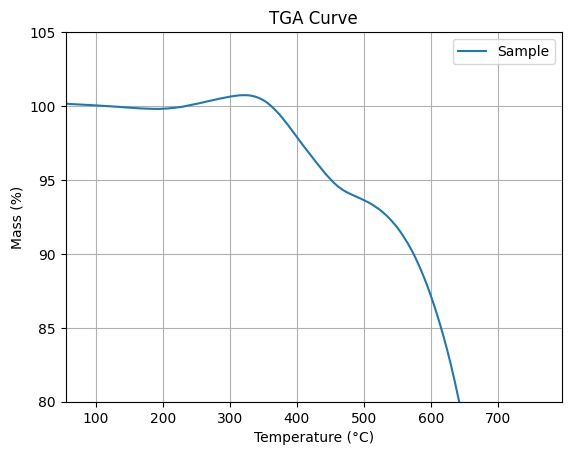

In [8]:
plot_tga(TGA_DFs[0])

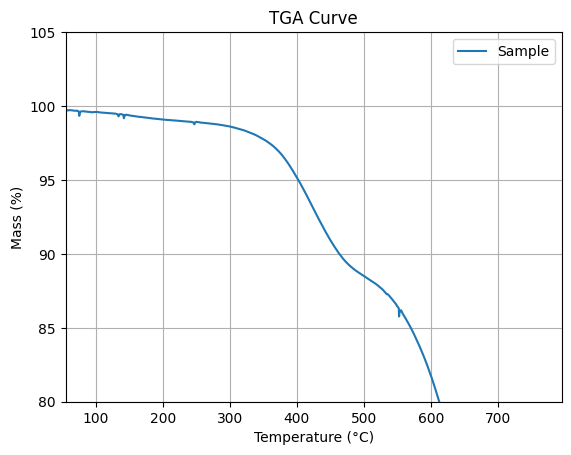

In [9]:
plot_tga(TGA_DFs[1])

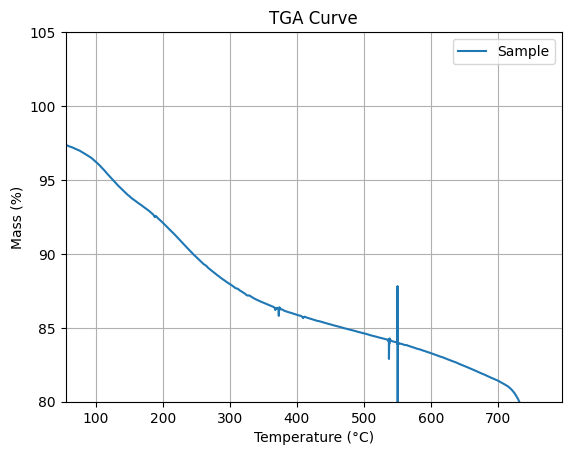

In [10]:
plot_tga(TGA_DFs[2])

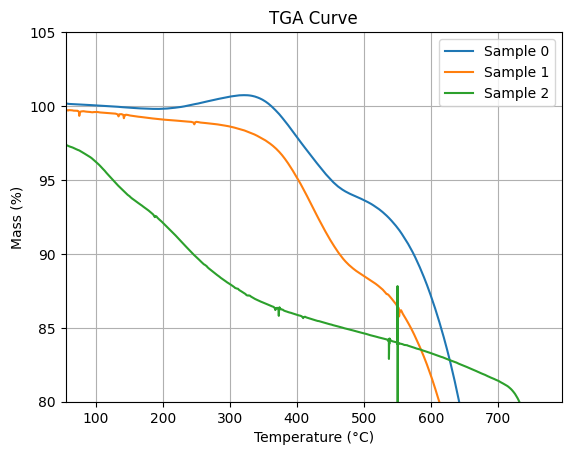

In [11]:
plot_tga(TGA_DFs)

In [12]:
import numpy as np
import pandas as pd

def compute_dtg(df, step=1.0, smooth_window=10):
    df = df.copy()
    
    # --- 1. Clean data ---
    df = df.dropna(subset=["Temperature", "Mass (%)"])
    df = df.sort_values("Temperature")
    df = df.drop_duplicates(subset="Temperature")
    
    # Remove non-increasing temperature steps (important!)
    df = df[df["Temperature"].diff().fillna(1) > 0]
    
    # --- 2. Resample to uniform temperature grid ---
    t_min, t_max = df["Temperature"].min(), df["Temperature"].max()
    temp_uniform = np.arange(t_min, t_max, step)
    
    mass_uniform = np.interp(temp_uniform, df["Temperature"], df["Mass (%)"])
    
    # --- 3. Light smoothing (like datasmooth in MATLAB) ---
    if smooth_window > 1:
        mass_uniform = (
            pd.Series(mass_uniform)
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
            .values
        )
    
    # --- 4. Compute derivative ---
    dmdt = np.gradient(mass_uniform, temp_uniform)
    
    # --- 5. Optional second smoothing (DTG cleanup) ---
    if smooth_window > 1:
        dmdt = (
            pd.Series(dmdt)
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
            .values
        )
    
    # --- 6. Flip sign (DTG convention) ---
    dmdt = -dmdt
    
    return pd.DataFrame({
        "Temperature": temp_uniform,
        "DTG (%/°C)": dmdt
    })



dTGA = [compute_dtg(df) for df in TGA_DFs]

In [15]:
def plot_dtg(data):
    plt.figure()
    
    # --- SINGLE DATAFRAME ---
    if not isinstance(data, list):
        df = data
        
        plt.plot(df["Temperature"], df["DTG (%/°C)"], label="Sample")
        
        y_min = df["DTG (%/°C)"].min()
        y_max = df["DTG (%/°C)"].max()
    
    # --- LIST OF DATAFRAMES ---
    else:
        y_min = np.inf
        y_max = -np.inf
        
        for i, df in enumerate(data):
            plt.plot(df["Temperature"], df["DTG (%/°C)"], label=f"Sample {i}")
            
            y_min = min(y_min, df["DTG (%/°C)"].min())
            y_max = max(y_max, df["DTG (%/°C)"].max())
    
    # --- PLOT SETTINGS ---
    plt.xlabel("Temperature (°C)")
    plt.ylabel("DTG (%/°C)")
    plt.title("DTG Curve")
    
    plt.xlim(55, 1000)
    plt.ylim(-0.01, 0.6)  # add margin
    
    plt.legend()
    plt.grid(True)
    
    plt.show()

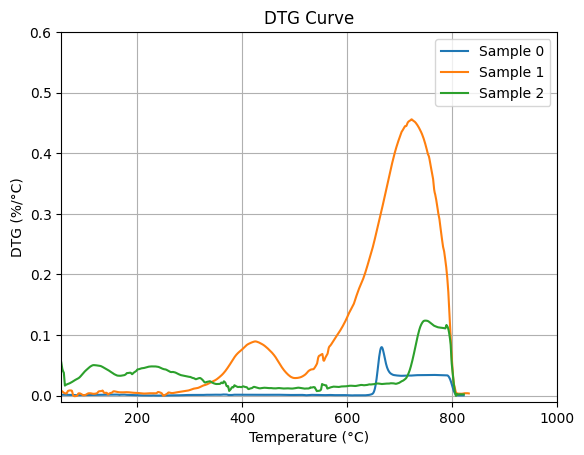

In [16]:
plot_dtg(dTGA)